In [36]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib  inline 

# Step 1: Dataset Selection

In [37]:
df=pd.read_csv('./data_set/Ecommerce_dataset_updated.csv')

# Step 2: Data Preparation

In [38]:
df.head()

,order_id,order_date,order_year,order_month,order_day,order_hour,order_minute,order_second,is_weekend,order_status,...,quarter,day_of_week,customer_segment_Regular,customer_segment_VIP,average_order_value,profit_per_unit,account_creation_year,account_creation_month,account_creation_dayofweek,account_age_days
0,ORD-5A2JR,2024-02-03 04:31:57.621140,2024,2,3,4,31,57,1,1.0,...,1,5,0,0,496.32,114.020000,2022,7,5,574
1,ORD-C4O76,2024-02-03 04:33:50.281606,2024,2,3,4,33,50,1,1.0,...,1,5,0,0,92.38,10.835000,2021,9,6,860
2,ORD-MIP58,2024-02-03 04:34:13.452841,2024,2,3,4,34,13,1,1.0,...,1,5,1,0,1191.02,121.316667,2022,1,6,734
3,ORD-A9GBX,2024-02-03 04:34:14.421205,2024,2,3,4,34,14,1,0.0,...,1,5,1,0,197.17,54.150000,2022,5,3,639
4,ORD-MI6OD,2024-02-03 04:35:56.872135,2024,2,3,4,35,56,1,0.0,...,1,5,1,0,53.10,13.480000,2021,7,4,932


In [39]:
df.describe()

,order_year,order_month,order_day,order_hour,order_minute,order_second,is_weekend,order_status,gender,age,...,quarter,day_of_week,customer_segment_Regular,customer_segment_VIP,average_order_value,profit_per_unit,account_creation_year,account_creation_month,account_creation_dayofweek,account_age_days
count,1.000123e+06,1.000123e+06,1.000123e+06,1.000123e+06,1.000123e+06,1.000123e+06,1.000123e+06,950022.000000,1.000123e+06,1.000123e+06,...,1.000123e+06,1.000123e+06,1.000123e+06,1.000123e+06,1.000123e+06,1.000123e+06,1.000123e+06,1.000123e+06,1.000123e+06,1.000123e+06
mean,2.024590e+03,6.514849e+00,1.575253e+01,1.148814e+01,2.949467e+01,2.948548e+01,2.870667e-01,1.158073,5.001185e-01,4.649414e+01,...,2.506289e+00,3.001995e+00,5.992213e-01,1.004116e-01,4.032363e+02,5.368110e+01,2.022600e+03,6.386341e+00,2.996094e+00,7.311725e+02
std,5.758891e-01,3.448711e+00,8.799790e+00,6.918078e+00,1.730984e+01,1.732781e+01,4.523932e-01,0.743871,5.000002e-01,1.673373e+01,...,1.117116e+00,2.003089e+00,4.900565e-01,3.005482e-01,3.701324e+02,4.316658e+01,1.216318e+00,3.391970e+00,1.999886e+00,4.394731e+02
min,2.024000e+03,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,1.800000e+01,...,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,7.530000e+00,5.566667e-01,2.021000e+03,1.000000e+00,0.000000e+00,1.000000e+00
25%,2.024000e+03,4.000000e+00,8.000000e+00,5.000000e+00,1.400000e+01,1.400000e+01,0.000000e+00,1.000000,0.000000e+00,3.200000e+01,...,2.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,1.390200e+02,2.231000e+01,2.022000e+03,3.000000e+00,1.000000e+00,3.570000e+02
50%,2.025000e+03,7.000000e+00,1.600000e+01,1.100000e+01,3.000000e+01,2.900000e+01,0.000000e+00,1.000000,1.000000e+00,4.600000e+01,...,3.000000e+00,3.000000e+00,1.000000e+00,0.000000e+00,2.901900e+02,4.254500e+01,2.023000e+03,6.000000e+00,3.000000e+00,7.160000e+02
75%,2.025000e+03,1.000000e+01,2.300000e+01,1.700000e+01,4.400000e+01,4.400000e+01,1.000000e+00,1.000000,1.000000e+00,6.100000e+01,...,4.000000e+00,5.000000e+00,1.000000e+00,0.000000e+00,5.457600e+02,7.188200e+01,2.024000e+03,9.000000e+00,5.000000e+00,1.074000e+03
max,2.026000e+03,1.200000e+01,3.100000e+01,2.300000e+01,5.900000e+01,5.900000e+01,1.000000e+00,3.000000,1.000000e+00,7.500000e+01,...,4.000000e+00,6.000000e+00,1.000000e+00,1.000000e+00,2.499750e+03,2.996200e+02,2.026000e+03,1.200000e+01,6.000000e+00,1.827000e+03


In [40]:
df.columns

Index(['order_id', 'order_date', 'order_year', 'order_month', 'order_day',
       'order_hour', 'order_minute', 'order_second', 'is_weekend',
       'order_status', 'customer_id', 'customer_name', 'gender', 'age',
       'country', 'city', 'customer_loyalty_score', 'total_orders_by_customer',
       'account_creation_date', 'product_id', 'product_name', 'category',
       'sub_category', 'brand', 'product_rating_avg', 'product_reviews_count',
       'stock_quantity', 'unit_price_usd', 'quantity', 'discount_percent',
       'discount_amount_usd', 'total_price_usd', 'cost_usd', 'profit_usd',
       'tax_usd', 'currency', 'payment_method', 'payment_status',
       'installment_plan', 'shipping_method', 'shipping_cost_usd',
       'delivery_days', 'shipping_country', 'warehouse_location',
       'delivery_status', 'rating', 'review_sentiment', 'customer_feedback',
       'coupon_used', 'coupon_code', 'campaign_source', 'device_type',
       'traffic_source', 'session_duration_minutes', 'pa

In [41]:
df.isnull().sum().sort_values(ascending=False)

order_status                  50101
order_id                          0
order_year                        0
order_month                       0
order_day                         0
                              ...  
profit_per_unit                   0
account_creation_year             0
account_creation_month            0
account_creation_dayofweek        0
account_age_days                  0
Length: 70, dtype: int64

In [42]:

(df["order_status"].median())

np.float64(1.0)

In [43]:
(df["order_status"].isnull().sum()/len(df))*100

np.float64(5.009483833488481)

In [44]:
df["order_status"] = df["order_status"].fillna(df["order_status"].mean())

# Step 3: Feature Engineering

In [45]:
daily_sales = (
    df.groupby("order_date")["total_price_usd"]
      .sum()
      .reset_index()
)

daily_sales = daily_sales.sort_values("order_date").reset_index(drop=True)

daily_sales.head()

,order_date,total_price_usd
0,2024-02-03 04:31:57.621140,496.32
1,2024-02-03 04:33:50.281606,92.38
2,2024-02-03 04:34:13.452841,1191.02
3,2024-02-03 04:34:14.421205,197.17
4,2024-02-03 04:35:56.872135,53.10


In [46]:
# 2. Convert date back to datetime
daily_sales["order_date"] = pd.to_datetime(daily_sales["order_date"])

# 3. Rename sales column
daily_sales = daily_sales.rename(
    columns={"total_price_usd": "sales"}
)


In [47]:
daily_sales = daily_sales.sort_values("order_date").reset_index(drop=True)

In [48]:
daily_sales["year"] = daily_sales["order_date"].dt.year
daily_sales["month"] = daily_sales["order_date"].dt.month
daily_sales["day"] = daily_sales["order_date"].dt.day
daily_sales["day_of_week"] = daily_sales["order_date"].dt.dayofweek
daily_sales["quarter"] = daily_sales["order_date"].dt.quarter
daily_sales["is_weekend"] = (
    daily_sales["day_of_week"] >= 5
).astype(int)

In [49]:
# 6. Lag features
daily_sales["lag_1"] = daily_sales["sales"].shift(1)
daily_sales["lag_7"] = daily_sales["sales"].shift(7)
daily_sales["lag_30"] = daily_sales["sales"].shift(30)

# 7. Rolling averages
daily_sales["rolling_7"] = (
    daily_sales["sales"]
    .shift(1)
    .rolling(7)
    .mean()
)


In [50]:
daily_sales["rolling_30"] = (
    daily_sales["sales"]
    .shift(1)
    .rolling(30)
    .mean()
)

# 8. Remove missing values
daily_sales = daily_sales.dropna().reset_index(drop=True)

# Check result
print(daily_sales.head())
print("\nColumns:")
print(daily_sales.columns)
print("\nShape:", daily_sales.shape)

                  order_date    sales  year  month  day  day_of_week  quarter  \
0 2024-02-03 04:57:29.695830   598.84  2024      2    3            5        1   
1 2024-02-03 04:57:29.889540   380.62  2024      2    3            5        1   
2 2024-02-03 04:57:30.923728  1011.13  2024      2    3            5        1   
3 2024-02-03 04:57:33.341282  1045.95  2024      2    3            5        1   
4 2024-02-03 04:58:55.998199    86.36  2024      2    3            5        1   

   is_weekend    lag_1    lag_7   lag_30   rolling_7  rolling_30  
0           1   112.38  1044.66   496.32  298.485714  339.644667  
1           1   598.84    63.71    92.38  234.797143  343.062000  
2           1   380.62   165.58  1191.02  280.070000  352.670000  
3           1  1011.13   435.57   197.17  400.862857  346.673667  
4           1  1045.95    71.23    53.10  488.060000  374.966333  

Columns:
Index(['order_date', 'sales', 'year', 'month', 'day', 'day_of_week', 'quarter',
       'is_weekend', 

In [51]:
features = [
    "year",
    "month",
    "day",
    "day_of_week",
    "quarter",
    "is_weekend",
    "lag_1",
    "lag_7",
    "lag_30",
    "rolling_7",
    "rolling_30"
]

X = daily_sales[features]
y = daily_sales["sales"]

print("X:", X.shape)
print("y:", y.shape)

X: (1000093, 11)
y: (1000093,)


# Step 4: Model Development


In [52]:
split = int(len(daily_sales) * 0.80)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (800074, 11)
X_test: (200019, 11)
y_train: (800074,)
y_test: (200019,)


In [53]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Linear Regression completed.")

Linear Regression completed.


In [54]:
from sklearn.ensemble import RandomForestRegressor

# Use a smaller sample for Random Forest
sample_size = 100000

X_rf_train = X_train.iloc[:sample_size]
y_rf_train = y_train.iloc[:sample_size]

rf_model = RandomForestRegressor(
    n_estimators=50,
    max_depth=15,
    random_state=42,
    n_jobs=2
)

rf_model.fit(X_rf_train, y_rf_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest completed successfully.")

Random Forest completed successfully.


# Step 5: Model Evaluation

In [55]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Linear Regression metrics
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

# Random Forest metrics
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

# Compare models
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse],
    "R2 Score": [lr_r2, rf_r2]
})

print(results)

best_model = results.loc[results["R2 Score"].idxmax(), "Model"]

print("Best Performing Model:", best_model)

               Model         MAE        RMSE  R2 Score
0  Linear Regression  272.820416  370.106317 -0.000029
1      Random Forest  273.562509  370.764327 -0.003588
Best Performing Model: Linear Regression


# Step 6: Business Insights

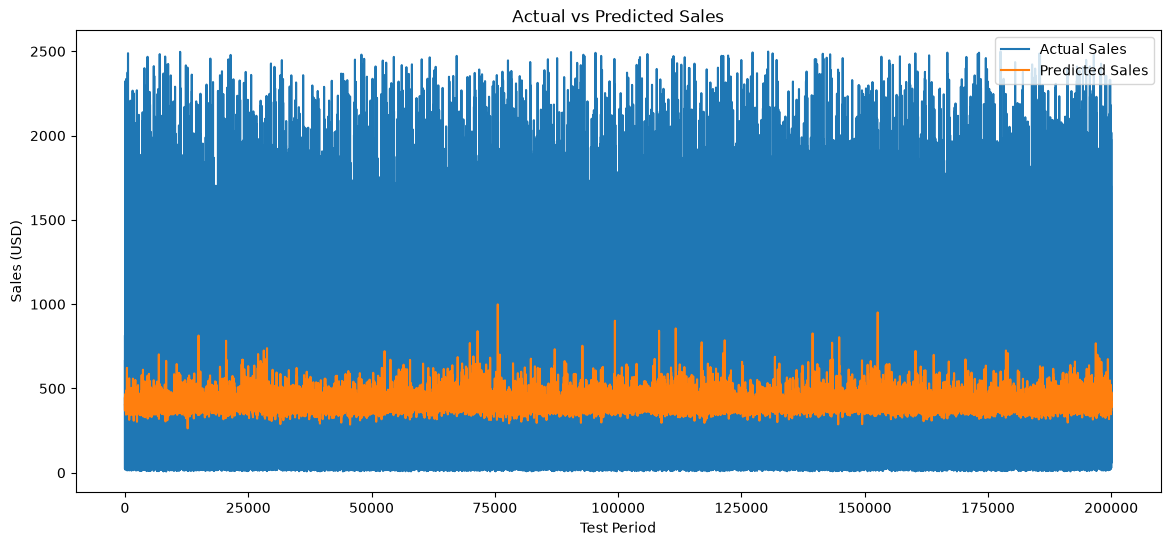

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(y_test.values, label="Actual Sales")
plt.plot(rf_pred, label="Predicted Sales")

plt.title("Actual vs Predicted Sales")
plt.xlabel("Test Period")
plt.ylabel("Sales (USD)")
plt.legend()
plt.show()

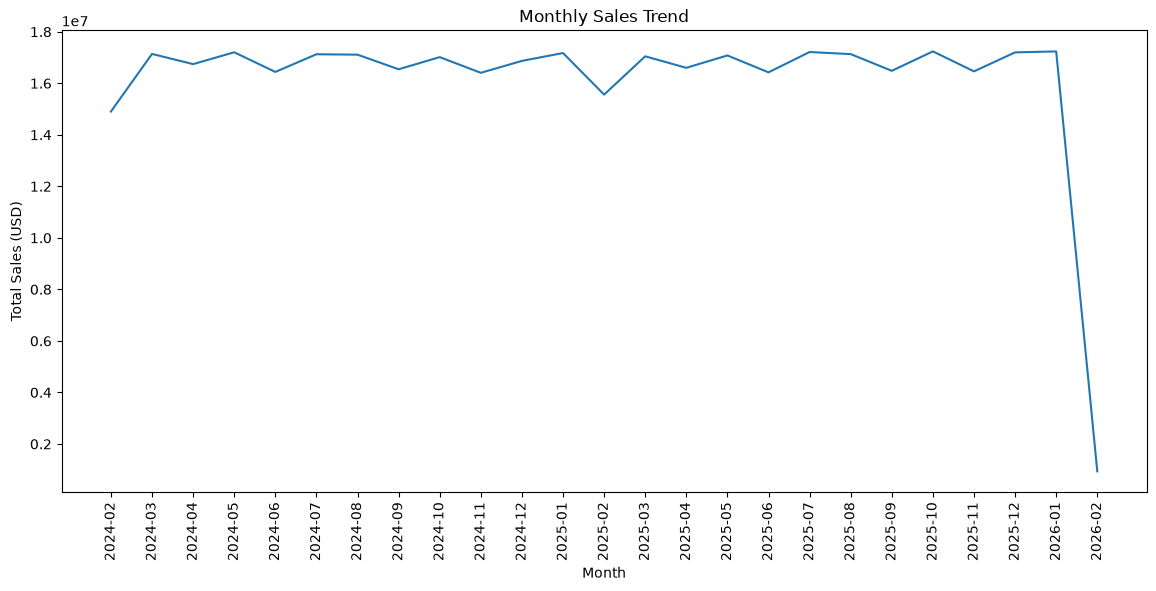

In [57]:
monthly_sales = (
    df.groupby(["order_year", "order_month"])["total_price_usd"]
      .sum()
      .reset_index()
)

monthly_sales["period"] = (
    monthly_sales["order_year"].astype(str)
    + "-"
    + monthly_sales["order_month"].astype(str).str.zfill(2)
)

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales["period"],
    monthly_sales["total_price_usd"]
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales (USD)")
plt.xticks(rotation=90)
plt.show()

In [58]:
quarterly_sales = (
    df.groupby("quarter")["total_price_usd"]
      .sum()
      .sort_values(ascending=False)
)

print(quarterly_sales)

quarter
3    1.016093e+08
4    1.011903e+08
2    1.004918e+08
1    9.999448e+07
Name: total_price_usd, dtype: float64


In [59]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

print(importance)

        Feature  Importance
9     rolling_7    0.177745
10   rolling_30    0.172239
6         lag_1    0.171911
8        lag_30    0.168798
7         lag_7    0.167827
2           day    0.075242
3   day_of_week    0.039161
1         month    0.015617
5    is_weekend    0.006243
4       quarter    0.005217
0          year    0.000000


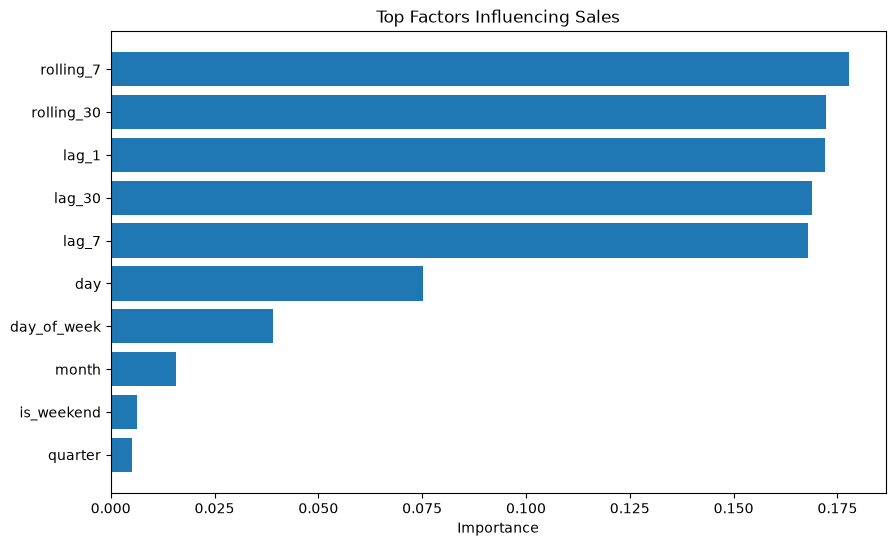

In [60]:
plt.figure(figsize=(10, 6))

plt.barh(
    importance["Feature"].head(10)[::-1],
    importance["Importance"].head(10)[::-1]
)

plt.title("Top Factors Influencing Sales")
plt.xlabel("Importance")
plt.show(
    
)

In [61]:
inventory_demand = (
    df.groupby("product_name")["quantity"]
      .sum()
      .sort_values(ascending=False)
)

print(inventory_demand.head(10))

product_name
Water Bottle Insulated    67853
Vacuum Robot Cleaner      67703
Tennis Balls Pack         67482
Cotton T-Shirt Pack       67219
Gym Gloves                67215
Storage Box Set           67130
LED Strip Lights 5m       67124
Treadmill Folding         67109
Resistance Bands Set      67042
Desk Lamp LED             66928
Name: quantity, dtype: int64


In [62]:
promotion_sales = (
    df.groupby("coupon_used")["total_price_usd"]
      .agg(["sum", "mean", "count"])
      .reset_index()
)

print(promotion_sales)

   coupon_used           sum        mean   count
0            0  2.015384e+08  403.009957  500083
1            1  2.017474e+08  403.462581  500040


In [63]:
campaign_sales = (
    df.groupby("campaign_source")["total_price_usd"]
      .agg(["sum", "mean", "count"])
      .sort_values("sum", ascending=False)
)

print(campaign_sales)

                         sum        mean   count
campaign_source                                 
Google Ads       67330349.95  403.700317  166783
Instagram        67304840.51  404.175017  166524
Facebook         67223369.96  402.479718  167023
Organic          67193173.01  401.750501  167251
Email            67143517.37  403.370965  166456
Affiliate        67090606.20  403.951002  166086
